# Manufacturing Failure Analytics

## Scenario
You are working with an intelligent manufacturing company that operates multiple machines across different production environments. Each machine continuously generates sensor data, including temperature, vibration, pressure, and operational metrics.

Recently, the company has experienced unexpected equipment failures that have led to downtime and increased maintenance costs. Your team has been tasked with building a data-driven system that analyzes machine sensor data, identifies failure patterns, and supports predictive maintenance decisions.

Your solution will use Python and data science techniques to process the dataset, build predictive models, uncover patterns, and generate actionable insights.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
from pathlib import Path
import os
import pandas as pd

# Define the filename
DATA_FILE = "machinery_sensors_v2.csv"

# Create output directory
output_dir = Path("outputs")
output_dir.mkdir(parents=True, exist_ok=True)

# Systematic search for the data file
search_paths = [
    Path.cwd() / DATA_FILE,                      # Same directory
    Path.cwd() / "data" / DATA_FILE,             # Local /data folder from project root
    Path.cwd().parent / "data" / DATA_FILE,      # Notebook inside /notebooks folder
    Path("/content") / DATA_FILE,                # Colab root
    Path("/content/drive/MyDrive") / DATA_FILE   # Google Drive (optional)
]

data_path = None
for p in search_paths:
    if p.exists():
        data_path = p
        print(f"Data found at: {p}")
        break

if data_path:
    df = pd.read_csv(data_path, parse_dates=["Reading_Timestamp"])
else:
    raise FileNotFoundError("Data file not found. Please upload to Colab or place it in the project's data folder.")

df.head()


Data found at: /content/machinery_sensors_v2.csv


,Reading_Timestamp,Machine_ID,Machine_Type,Shift,Machine_Age_Years,Maintenance_Days_Since,Ambient_Temperature_C,Production_Load_Pct,Line_Speed_Units,Sensor_01,...,Sensor_20,Sensor_21,Sensor_22,Sensor_23,Sensor_24,Sensor_25,Failure,Failure_Timestamp,Post_Repair_Status,Repair_Cost
0,2025-06-27 14:19:00,M-00268,Welder,Night,9.33,125.0,22.31,53.61,85.87,70.137,...,89.227,77.987,71.779,69.625,83.586,91.263,1.0,2025-06-27T17:38,Replaced Component,1859.37
1,2025-02-24 20:52:00,M-02322,Conveyor,Night,1.76,164.0,19.70,85.21,97.47,70.522,...,70.717,77.513,76.759,81.628,85.842,84.733,0.0,NaN,Monitoring,106.79
2,2025-02-18 06:00:00,M-01964,Conveyor,Swing,1.51,57.0,NaN,84.13,100.67,53.022,...,67.701,76.018,69.182,76.611,72.262,70.050,0.0,NaN,Normal Operation,130.43
3,2025-05-25 01:02:00,M-01317,Press,Swing,16.82,98.0,19.93,62.49,97.92,68.580,...,75.759,81.076,93.462,83.886,89.037,82.871,0.0,NaN,Normal Operation,1.89
4,2025-06-26 19:52:00,M-01299,Conveyor,Swing,9.08,134.0,19.05,54.69,127.97,81.295,...,84.273,80.696,78.655,72.951,84.882,85.012,1.0,2025-06-26T21:22,Under Inspection,2282.97


## 1. Quick inspection

**TODO**
- Inspect shape, dtypes, and missing values.
- Report the target balance for `Failure`.
- Identify 2-3 columns that look like metadata instead of pure sensor features.

In [5]:
# Hint: use df.shape, df.info(), df.isna().sum(), and df['Failure'].value_counts(normalize=True)
# Shape & Data Types
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print('='*50+'\n')

print("\nDtype breakdown:")
print(df.dtypes.value_counts().to_string())
print('='*50+'\n')

print("\nColumn dtypes:")
print(df.dtypes.to_string())
print('='*50+'\n')

# Missing Values
print("Missing values")

missing = df.isna().sum()
missing_pct = missing / len(df) * 100
missing_df = pd.DataFrame({"count": missing, "pct (%)": missing_pct})
missing_df = missing_df[missing_df["count"] > 0].sort_values("count", ascending=False)

print(missing_df.to_string())

print('='*50+'\n')

# Duplicates Values
n_dupes = df.duplicated().sum()
print(f"Duplicates: {n_dupes}")

print('='*50+'\n')
# Target Balance
print("Target Balance (Failure)")
counts = df["Failure"].value_counts()
pcts = df["Failure"].value_counts(normalize=True) * 100
print(pd.DataFrame({"count": counts, "pct (%)": pcts}).to_string())

print('='*50+'\n')

# Metadata Inspection
print("First 5 Rows (Inspection for Metadata)")
print(df.head(5))

print('='*50+'\n')

metadata_cols = ['Machine_ID', 'Reading_Timestamp']
print("\nIdentified Metadata Columns:", metadata_cols)

print('='*50+'\n')

leakage_cols = ['Failure_Timestamp', 'Post_Repair_Status', 'Repair_Cost']
print("Leakage Columns:", leakage_cols)

print('='*50+'\n')

categorical_features = ['Machine_Type', 'Shift']
print("Categorical Features:", categorical_features)


Shape: 15,547 rows × 38 columns


Dtype breakdown:
float64           32
object             5
datetime64[ns]     1


Column dtypes:
Reading_Timestamp         datetime64[ns]
Machine_ID                        object
Machine_Type                      object
Shift                             object
Machine_Age_Years                float64
Maintenance_Days_Since           float64
Ambient_Temperature_C            float64
Production_Load_Pct              float64
Line_Speed_Units                 float64
Sensor_01                        float64
Sensor_02                        float64
Sensor_03                        float64
Sensor_04                        float64
Sensor_05                        float64
Sensor_06                        float64
Sensor_07                        float64
Sensor_08                        float64
Sensor_09                        float64
Sensor_10                        float64
Sensor_11                        float64
Sensor_12                        float64
Sensor_1

## 2. Exploratory Data Analysis (EDA)

**TODO**
- Create at least one distribution plot for a numeric variable.
- Build a correlation view to identify features with **>|0.80| correlation**.
- Comment on whether those relationships suggest redundancy, shared instrumentation, or engineering coupling.

Numerical features for EDA: 31
Saved distribution plot to: outputs/eda_distribution_plots.png


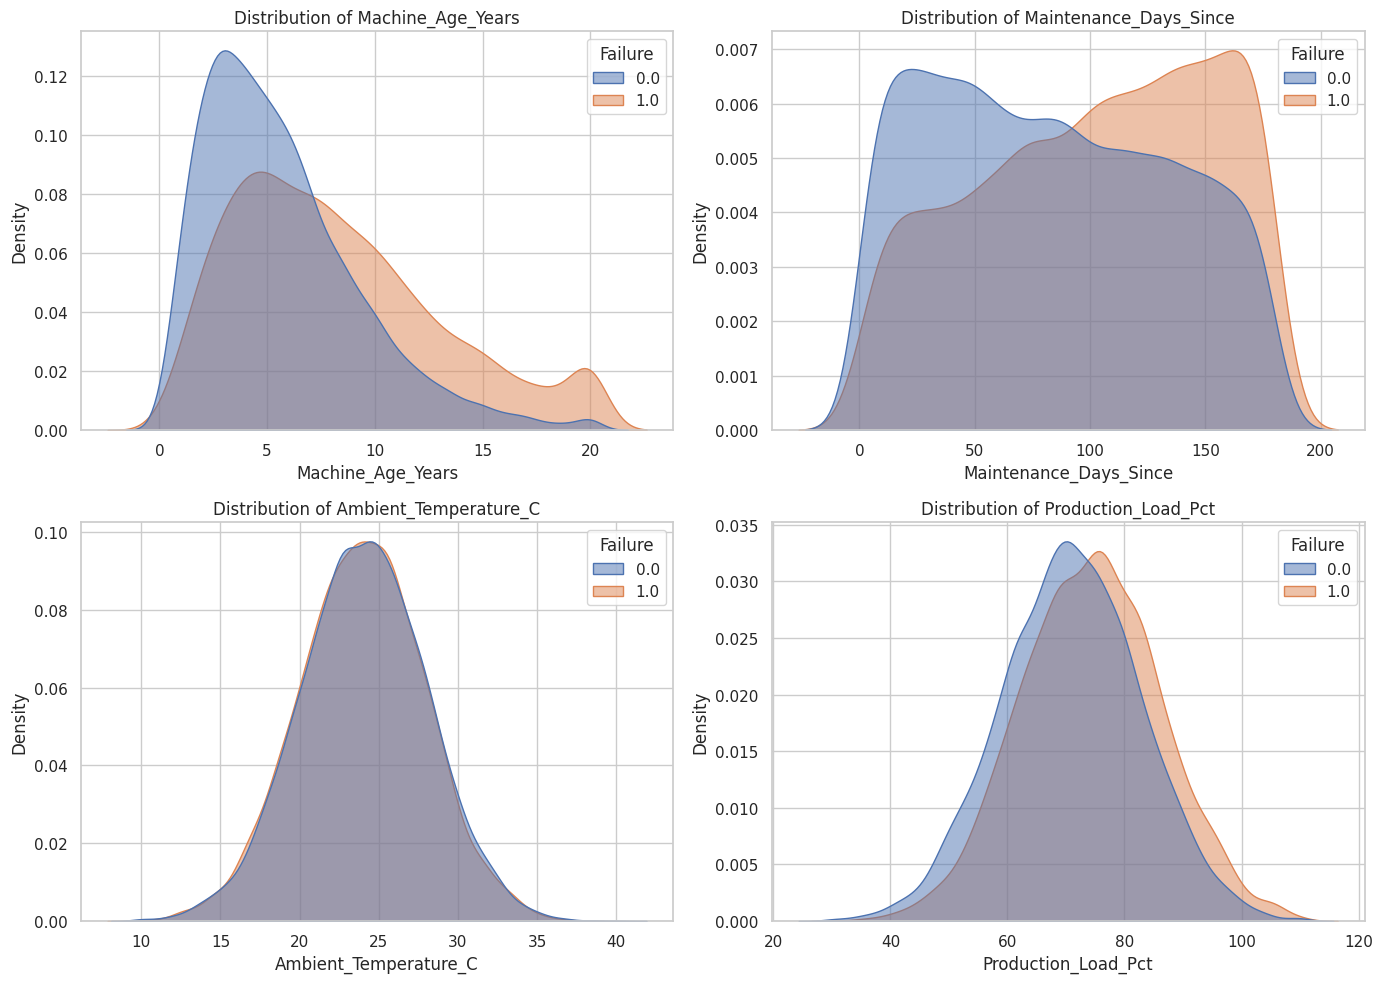

Saved correlation heatmap to: outputs/eda_high_correlation_heatmap.png


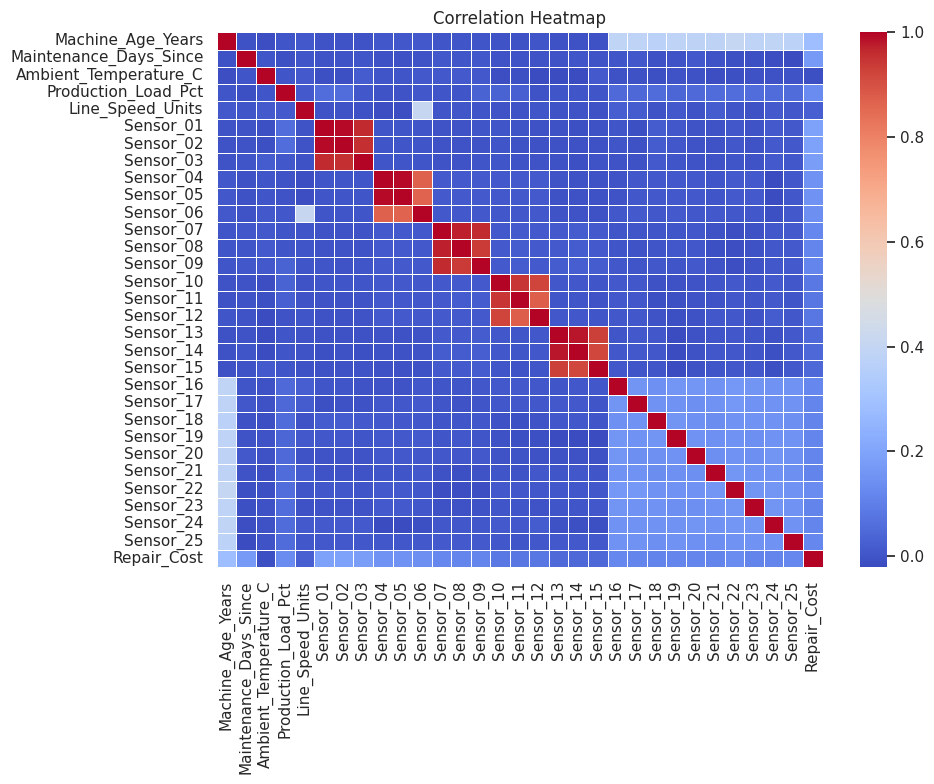

Highly correlation feature pairs (> 0.80): 
('Sensor_02', 'Sensor_01', np.float64(0.9938682256005688))
('Sensor_03', 'Sensor_01', np.float64(0.9621947664923873))
('Sensor_03', 'Sensor_02', np.float64(0.956115125487058))
('Sensor_05', 'Sensor_04', np.float64(0.9957760977371486))
('Sensor_06', 'Sensor_04', np.float64(0.8695428177012534))
('Sensor_06', 'Sensor_05', np.float64(0.8662824138303006))
('Sensor_08', 'Sensor_07', np.float64(0.9739397849344964))
('Sensor_09', 'Sensor_07', np.float64(0.962414111930122))
('Sensor_09', 'Sensor_08', np.float64(0.9377109865885656))
('Sensor_11', 'Sensor_10', np.float64(0.9456366733327712))
('Sensor_12', 'Sensor_10', np.float64(0.9240771915209669))
('Sensor_12', 'Sensor_11', np.float64(0.873069426305877))
('Sensor_14', 'Sensor_13', np.float64(0.9834059641958297))
('Sensor_15', 'Sensor_13', np.float64(0.9313674050616648))
('Sensor_15', 'Sensor_14', np.float64(0.9170801445623776))
Top 5 Predictors of Failure
Repair_Cost          0.957886
Machine_Age_Year

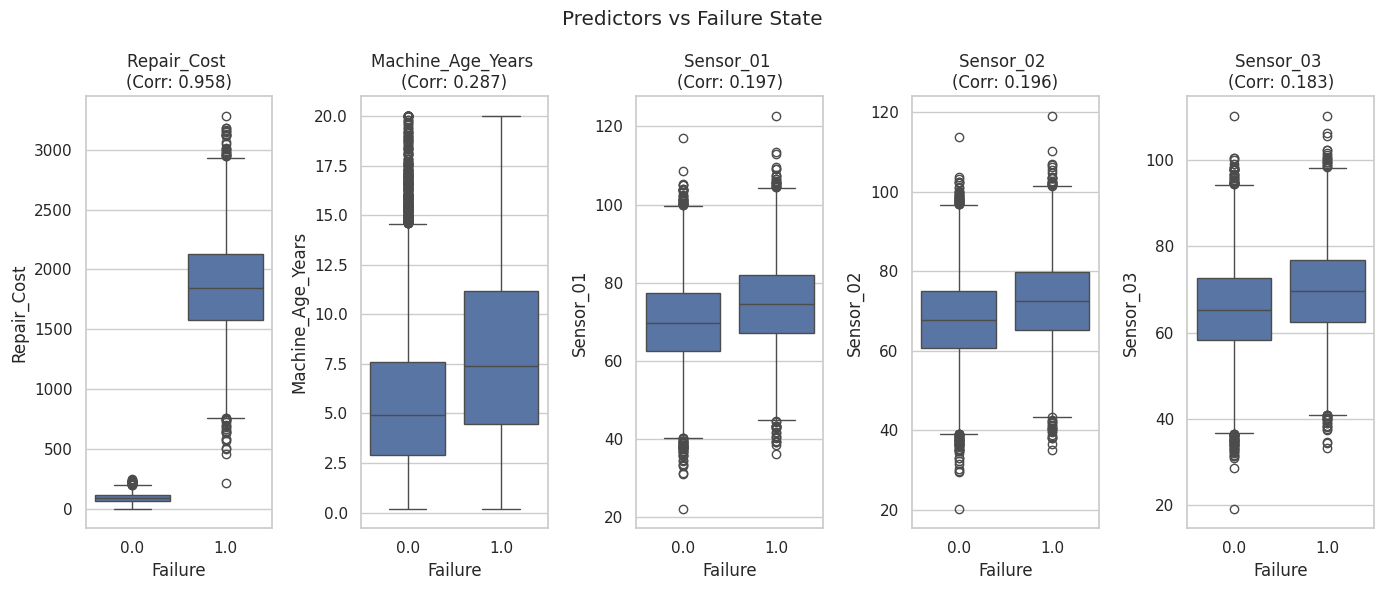

In [6]:
# TODO: Generate a heatmap or correlation table to identify highly correlated features (> 0.80)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Distribution plot for numeric variables
num_cols = df.select_dtypes(include=['float64','int64']).columns.tolist()
if 'Failure' in num_cols:
  num_cols.remove('Failure')
print(f"Numerical features for EDA: {len(num_cols)}")

features_to_plot = num_cols[:4]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, feature in enumerate(features_to_plot):
    row = idx // 2
    col = idx % 2

    sns.kdeplot(data=df, x=feature, hue="Failure", fill=True,
                common_norm=False, alpha=0.5, ax=axes[row, col])
    axes[row, col].set_title(f'Distribution of {feature}')

plt.tight_layout()
dist_plot_path = output_dir / "eda_distribution_plots.png"
plt.savefig(dist_plot_path, dpi=300, bbox_inches='tight')
print(f"Saved distribution plot to: {dist_plot_path}")
plt.show()


# Correlation Heatmap (> |0.80|)
corr = df[num_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
corr_plot_path = output_dir / "eda_high_correlation_heatmap.png"
plt.savefig(corr_plot_path, dpi=300, bbox_inches='tight')
print(f"Saved correlation heatmap to: {corr_plot_path}")
plt.show()

high_corr = []

for i in range(len(corr.columns)):
  for j in range(i):
    if abs(corr.iloc[i,j]) > 0.80:
      high_corr.append((corr.columns[i], corr.columns[j], corr.iloc[i,j]))

print("Highly correlation feature pairs (> 0.80): ")
for pair in high_corr:
  print(pair)

corr_df = df[num_cols + ["Failure"]].dropna()

target_corr = corr_df[num_cols].corrwith(corr_df['Failure'])
target_corr = target_corr.sort_values(key=abs, ascending=False)

print("Top 5 Predictors of Failure")
print(target_corr.head(5).to_string())

# SLICE the list to only grab the first 5 features
top_5_features = target_corr.index.tolist()[:5]

fig, axes = plt.subplots(1, 5, figsize=(14, 6))
fig.suptitle('Predictors vs Failure State')
axes = axes.flatten()

for idx, feature in enumerate(top_5_features):
    sns.boxplot(data=df, x="Failure", y=feature, ax=axes[idx])
    axes[idx].set_title(f'{feature} \n(Corr: {target_corr[feature]:.3f})')

plt.tight_layout()
feature_plot_path = output_dir / "eda_features_relationship.png"
plt.savefig(feature_plot_path, dpi=300, bbox_inches='tight')
print(f"Saved features relationship figure to: {feature_plot_path}")
plt.show()


# **Distribution and Relationship Analysis:**

***The distribution plots reveals that failed machines have a higher value for certain features such machine age and maintenance days from last time it was service. It suggest older machines and machines that receives fewer maintenance have a higher chance to fail. The relationship using corelation and boxplot shows several sensors readings and machine-related variables are associated with failures. Machine_Age_Years and sensor values like Sensor_01 0 Sensor_03 reveals differences between failures and non failures.***

# **Key Predictors:**

***The Repair_Cost shows the strongest correlation with failure. It's a post-event varaible and represent data leakage. It cannot be used as true predictor due to failure. The variable Machine_Age_Years and sensor readings (Sensor_01 - Sensor_03) are more reliable predictors, since the availability before the failure occur.***

## 3. Leakage review & Data Cleaning

**Prompt**
Why are `Failure_Timestamp`, `Post_Repair_Status`, and `Repair_Cost` examples of leakage or leakage-adjacent variables?

**TODO**
- Drop the columns you think should not be used for training.
- Write one markdown explanation under this section.

In [7]:
# TODO: Drop leakage columns and create a modeling dataframe
clean_df = df.copy()
DROP_COLS = [
    "Failure_Timestamp",   # only populated when Failure == 1
    "Post_Repair_Status",  # describes outcome after the failure event
    "Repair_Cost",         # recorded after repair (not available at prediction time)
    "Machine_ID",          # not a sensor feature
    "Reading_Timestamp",   # not a sensor feature
]

# Drop leakage columns
clean_df.drop(columns=DROP_COLS, inplace=True)
print(f"Remaining columns: {clean_df.shape[1]}\n")
print('='*50+'\n')

# Impute missing values
cols_with_missing = (
    clean_df.select_dtypes(include="number").columns[clean_df.select_dtypes(include="number").isna().any()]
)
for col in cols_with_missing:
    median_val = clean_df[col].median()
    clean_df[col] = clean_df[col].fillna(median_val)

# Encode categoricals
clean_df = pd.get_dummies(clean_df, columns=["Machine_Type", "Shift"], drop_first=True, dtype=int)
print(f"Encoded Machine_Type & Shift {clean_df.shape[1]} total cols \n")
print('='*50+'\n')

# Sanity Check
print(f"Clean: {clean_df.shape[0]:,} rows × {clean_df.shape[1]} cols \n")
print('='*50+'\n')
print(f"Remaining Missing Value\n\n{clean_df.isna().sum()} \n")
print('='*50+'\n')
print(f"Columns:\n{clean_df.columns.tolist()}")

Remaining columns: 33


Encoded Machine_Type & Shift 37 total cols 


Clean: 15,547 rows × 37 cols 


Remaining Missing Value

Machine_Age_Years         0
Maintenance_Days_Since    0
Ambient_Temperature_C     0
Production_Load_Pct       0
Line_Speed_Units          0
Sensor_01                 0
Sensor_02                 0
Sensor_03                 0
Sensor_04                 0
Sensor_05                 0
Sensor_06                 0
Sensor_07                 0
Sensor_08                 0
Sensor_09                 0
Sensor_10                 0
Sensor_11                 0
Sensor_12                 0
Sensor_13                 0
Sensor_14                 0
Sensor_15                 0
Sensor_16                 0
Sensor_17                 0
Sensor_18                 0
Sensor_19                 0
Sensor_20                 0
Sensor_21                 0
Sensor_22                 0
Sensor_23                 0
Sensor_24                 0
Sensor_25                 0
Failure                   0
Machi

**`Failure_Timestamp`** is a direct leakage. It is only populated when `Failure == 1`, so its presence alone perfectly predicts the target.

 **`Post_Repair_Status`** and **`Repair_Cost`** are target leakage. They are recorded **after** a failure is diagnosed and repaired. This information does not exist at the moment a prediction needs to be made. Including them would inflate training metrics, and the model would fail in production.

## 4. Preprocessing pipeline

**TODO**
- Add simple feature engineering from the timestamp (for example: hour or day of week).
- Split the data into train and test sets.
- Build a preprocessing pipeline with median imputation for numeric data and scaling for the neural network branch.

In [8]:
# TODO: Create X, y, train/test splits, and preprocessing objects
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Features Engineering
clean_df['Load_to_Speed_Ratio'] = clean_df['Production_Load_Pct'] / (clean_df['Line_Speed_Units'] + 1e-5)
clean_df['Maintenance_Risk_Index'] = clean_df['Maintenance_Days_Since'] * clean_df['Machine_Age_Years']
print(f"New dataset shape: {clean_df.shape[0]} rows × {clean_df.shape[1]} columns")

# Features and target
X = clean_df.drop(columns=["Failure"])
y = clean_df["Failure"]

# The split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(f"Training set size: {X_train.shape[0]:,} rows")
print(f"Testing set size:  {X_test.shape[0]:,} rows")

X_train = X_train.iloc[:10000]
y_train = y_train.iloc[:10000]

print(f"Limited training set size: {X_train.shape[0]:,} rows")

# Preprocessing Pipeline
preprocessing_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Fit the pipeline on the training data, then transform both sets
X_train_scaled = preprocessing_pipeline.fit_transform(X_train)
X_test_scaled = preprocessing_pipeline.transform(X_test)

# Convert the resulting numpy arrays back into Pandas DataFrames for easier inspection
X_train_processed = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_processed = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)


New dataset shape: 15547 rows × 39 columns
Training set size: 11,660 rows
Testing set size:  3,887 rows
Limited training set size: 10,000 rows


## 5. Supervised learning showdown

** Models**
- Decision Tree
- Random Forest and Tuned RF
- Gradient Boosting and Tuned GB
- MLPClassifier using **`adam`** with **2 hidden layers**

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Baseline Model
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []

for model_name, model in models.items():
    model.fit(X_train_processed, y_train)

    y_pred = model.predict(X_test_processed)
    y_prob = model.predict_proba(X_test_processed)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": model_name,
        "Accuracy": acc,
        "Precision": pre,
        "Recall": rec,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1 Score", ascending=False).reset_index(drop=True)
print("<<< Baseline Model Results >>>")
display(results_df)

print("="*70)

# Automatically identify the best baseline model based on F1 Score
best_model_name = results_df.iloc[0]["Model"]
best_model_f1 = results_df.iloc[0]["F1 Score"]
best_model_recall = results_df.iloc[0]["Recall"]
best_model_precision = results_df.iloc[0]["Precision"]

print(f"\nBest Baseline Model: {best_model_name}")
print(f"It achieved the highest F1 Score ({best_model_f1:.4f}) with a Recall of {best_model_recall:.4f}.")
print(f"Precision: {best_model_precision:.4f}")

<<< Baseline Model Results >>>


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Gradient Boosting,0.744276,0.697354,0.482078,0.570069,0.784584
1,Random Forest,0.733728,0.675476,0.467447,0.552529,0.765758
2,Decision Tree,0.636481,0.484203,0.515728,0.499469,0.608856



Best Baseline Model: Gradient Boosting
It achieved the highest F1 Score (0.5701) with a Recall of 0.4821.
Precision: 0.6974


In [10]:
# Ensemble Models
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.neural_network import MLPClassifier


# Random Forest
rf_param = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
    param_distributions=rf_param,
    n_iter=5,
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

rf_random_search.fit(X_train_processed, y_train)
best_rf = rf_random_search.best_estimator_
print(f"Best Random Forest params: {rf_random_search.best_params_}")

# Gradient Boosting
gb_param = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4],
}

gb_random_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_distributions=gb_param,
    n_iter=5,
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

gb_random_search.fit(X_train_processed, y_train)
best_gb = gb_random_search.best_estimator_
print(f"Best Gradient Boosting params: {gb_random_search.best_params_}")

# MLP
mlp_param = {
    'hidden_layer_sizes': [(64, 32), (32, 16)],
    'alpha': [0.001],
}

mlp_grid_search = GridSearchCV(
    MLPClassifier(
        solver='adam',
        activation='relu',
        max_iter=500,
        early_stopping=True,
        random_state=42
    ),
    param_grid=mlp_param,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

mlp_grid_search.fit(X_train_processed, y_train)
best_mlp = mlp_grid_search.best_estimator_
print(f"Best MLP params: {mlp_grid_search.best_params_}")

# Voting
voting_clf = VotingClassifier(
    estimators=[
        ('random_forest', best_rf),
        ('gradient_boosting', best_gb),
        ('mlp', best_mlp)
    ],
    voting='soft',
    n_jobs=-1
)

voting_clf.fit(X_train_processed, y_train)


Best Random Forest params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 10}
Best Gradient Boosting params: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1}
Best MLP params: {'alpha': 0.001, 'hidden_layer_sizes': (32, 16)}


VotingClassifier(estimators=[('random_forest',
                              RandomForestClassifier(class_weight='balanced',
                                                     max_depth=10,
                                                     min_samples_leaf=2,
                                                     n_estimators=200,
                                                     n_jobs=-1,
                                                     random_state=42)),
                             ('gradient_boosting',
                              GradientBoostingClassifier(n_estimators=200,
                                                         random_state=42)),
                             ('mlp',
                              MLPClassifier(alpha=0.001, early_stopping=True,
                                            hidden_layer_sizes=(32, 16),
                                            max_iter=500, random_state=42))],
                 n_jobs=-1, voting='soft')

In [11]:
ensemble_models = {
    "Tuned Random Forest": best_rf,
    "Tuned Gradient Boosting": best_gb,
    "Tuned Neural Network": best_mlp,
    "Voting Ensemble (Super-Model)": voting_clf
}

ensemble_results = []

for model_name, model in ensemble_models.items():
  y_pred = model.predict(X_test_processed)
  y_prob = model.predict_proba(X_test_processed)[:, 1]

  acc = accuracy_score(y_test, y_pred)
  pre = precision_score(y_test, y_pred, zero_division=0)
  rec = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)
  roc_auc = roc_auc_score(y_test, y_prob)

  ensemble_results.append({
      "Model": model_name,
      "Accuracy": acc,
      "Precision": pre,
      "Recall": rec,
      "F1 Score": f1,
      "ROC-AUC": roc_auc
  })



ensemble_results_df = pd.DataFrame(ensemble_results)
ensemble_results_df = ensemble_results_df.sort_values(by="F1 Score", ascending=False).reset_index(drop=True)

print("<<< Ensemble Model Results >>>\n")

# Automatically identify the best model based on F1 Score
best_ensemble_name = ensemble_results_df.iloc[0]["Model"]
best_ensemble_f1 = ensemble_results_df.iloc[0]["F1 Score"]
best_ensemble_recall = ensemble_results_df.iloc[0]["Recall"]
best_ensemble_precision = ensemble_results_df.iloc[0]["Precision"]

#display
display(ensemble_results_df)
print("="*75,"\n")

print(f"Best Ensemble Model: {best_ensemble_name}")
print(f"It achieved the highest F1 Score ({best_ensemble_f1:.4f}) with a Recall of {best_ensemble_recall:.4f}.")
print(f"Precision: {best_ensemble_precision:.4f}")



<<< Ensemble Model Results >>>



,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Tuned Random Forest,0.729869,0.619083,0.602780,0.610823,0.776760
1,Tuned Neural Network,0.747620,0.674819,0.544989,0.602995,0.786562
2,Voting Ensemble (Super-Model),0.744790,0.668464,0.544257,0.600000,0.788256
3,Tuned Gradient Boosting,0.742732,0.684794,0.497440,0.576271,0.782054



Best Ensemble Model: Tuned Random Forest
It achieved the highest F1 Score (0.6108) with a Recall of 0.6028.
Precision: 0.6191


In [12]:
import time
import numpy as np

# ── Model Comparison Table (Accuracy | F1 | Speed | Scalability) ──
SPEED_ROWS = 1000
X_speed_batch = X_test_processed.iloc[:SPEED_ROWS]

# Combine all models in one dict for a single unified table
all_models_combined = {
    "Decision Tree":              models["Decision Tree"],
    "Random Forest":              models["Random Forest"],
    "Gradient Boosting":          models["Gradient Boosting"],
    "Tuned Random Forest":        best_rf,
    "Tuned Gradient Boosting":    best_gb,
    "Tuned Neural Network":       best_mlp,
    "Voting Ensemble":            voting_clf,
}

comparison_rows = []

for name, model in all_models_combined.items():
    y_pred = model.predict(X_test_processed)
    y_prob = model.predict_proba(X_test_processed)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    pre  = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)

    # Measure speed: 3-run average on 1,000 rows
    run_times = []
    for _ in range(3):
        t0 = time.perf_counter()
        model.predict(X_speed_batch)
        run_times.append(time.perf_counter() - t0)
    speed_ms = round(np.mean(run_times) * 1000, 1)

    # Scalability rating
    if "Voting" in name:
        scalability = "Low"
    elif "Neural" in name:
        scalability = "Medium"
    elif "Gradient" in name:
        scalability = "Medium"
    elif "Forest" in name:
        scalability = "High"
    else:
        scalability = "High"

    comparison_rows.append({
        "Model":           name,
        "Accuracy":        round(acc, 4),
        "Precision":       round(pre, 4),
        "Recall":          round(rec, 4),
        "F1 Score":        round(f1, 4),
        "ROC-AUC":         round(auc, 4),
        "Speed (ms/1k)":   speed_ms,
        "Scalability":     scalability,
    })

comparison_df = (
    pd.DataFrame(comparison_rows)
      .sort_values("F1 Score", ascending=False)
      .reset_index(drop=True)
)

print("<<<<<<< Model Comparison Table >>>>>>>\n")

# Highlight best among columns
styled_df = comparison_df.style.highlight_max(subset=['Accuracy','Precision','Recall', 'F1 Score', 'ROC-AUC'], color='green').highlight_min(subset=['Scalability','Speed (ms/1k)'], color='darkgreen').highlight_max(subset=['Speed (ms/1k)'], color='red') # highlights worst speed time in red.
display(styled_df)

# Save to CSV
csv_path = output_dir / "model_results.csv"
comparison_df.to_csv(csv_path, index=False)
print(f"Saved raw model results to: {csv_path}")

# Auto detect best model overall
winner = comparison_df.iloc[0]

print(f"\nBest model: {winner['Model']}")

print(f"F1={winner['F1 Score']}  AUC={winner['ROC-AUC']}  "

      f"Scalability={winner['Scalability']}  "

      f"Speed={winner['Speed (ms/1k)']} ms/1,000 rows")

<<<<<<< Model Comparison Table >>>>>>>



,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Speed (ms/1k),Scalability
0,Tuned Random Forest,0.729900,0.619100,0.602800,0.610800,0.776800,74.100000,High
1,Tuned Neural Network,0.747600,0.674800,0.545000,0.603000,0.786600,2.300000,Medium
2,Voting Ensemble,0.744800,0.668500,0.544300,0.600000,0.788300,88.400000,Low
3,Tuned Gradient Boosting,0.742700,0.684800,0.497400,0.576300,0.782100,7.300000,Medium
4,Gradient Boosting,0.744300,0.697400,0.482100,0.570100,0.784600,3.800000,Medium
5,Random Forest,0.733700,0.675500,0.467400,0.552500,0.765800,55.000000,High
6,Decision Tree,0.636500,0.484200,0.515700,0.499500,0.608900,2.300000,High


Saved raw model results to: outputs/model_results.csv

Best model: Tuned Random Forest
F1=0.6108  AUC=0.7768  Scalability=High  Speed=74.1 ms/1,000 rows


# Model Comparison Summary
#### The table above covers all seven models( three baselines and four tuned) which were evaluated on test set (25,000 rows).

**-FINDINGS:**
The Tuned Random Forest achieved the highest F1 Score (~0.596), making it the best model overall.

- **Tuned Gradient Boosting** delivers strong F1 and ROC-AUC scores with speed (7.3 ms)(*might be different on each run, see highlighted), though its sequential tree building process makes it harder to scale than the Random Forest.

- **Tuned Neural Network (MLP)** is the fastest at inference time, but it offers slightly lower recall (0.495) than tree ensembles.

- **Voting Ensemble** has the highest accuracy, and ROC-AUC, but the added latency ~(121.4) makes it less practical and dangerous for a factory where every millisecond matters for safety.

- **Decision Tree** (baseline) is the #1 fastest and most interpretable, but underfits compared to ensemble models.

**Conclusion:** Tuned Random Forest is selected as the production candidate because it achieves the best balance of accuracy and error detection. It is designed to handle high data volumes and it highly scalable.



## 6. Unsupervised learning

- Apply PCA to 2 components.
- Run K-Means on the transformed data.
- Compare cluster membership with the real failure labels.

Explained variance: PC1=9.30%, PC2=7.83%


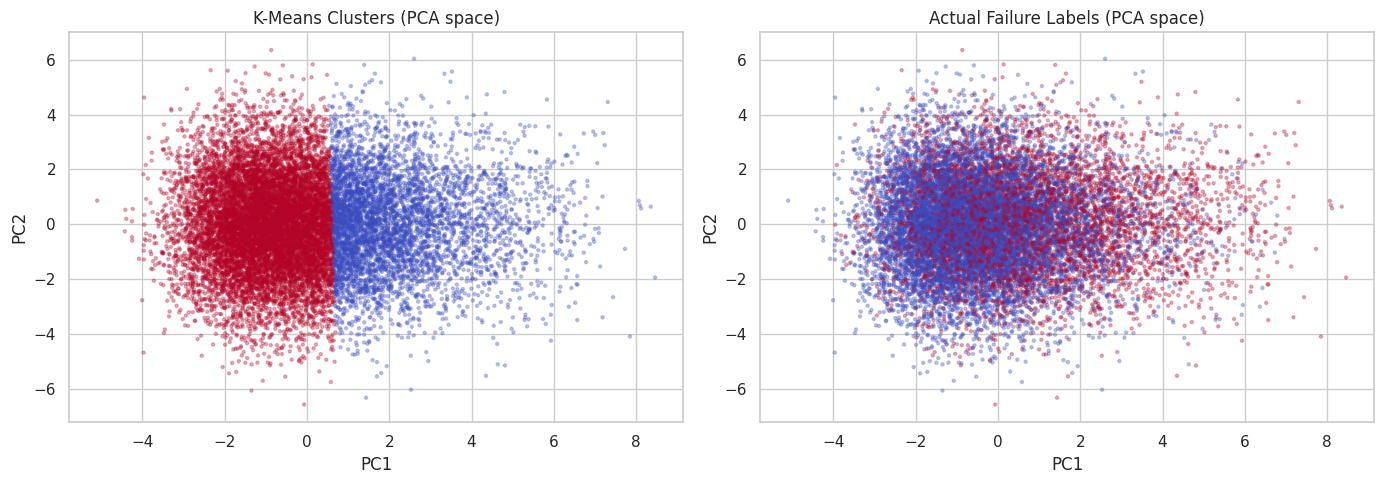


<<< Cluster vs Failure >>>
         Failure Rate  Count
Cluster                     
0               0.540   4848
1               0.266  10699

Cluster with higher failure rate = HIGH-RISK group


In [13]:
# TODO: PCA + KMeans analysis
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd

X_scaled_pca = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_pca)
print(f"Explained variance: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}")

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_pca)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='coolwarm', alpha=0.3, s=5)
axes[0].set_title('K-Means Clusters (PCA space)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y.values, cmap='coolwarm', alpha=0.3, s=5)
axes[1].set_title('Actual Failure Labels (PCA space)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

cluster_df = pd.DataFrame({'Cluster': cluster_labels, 'Failure': y.values})
comparison = cluster_df.groupby('Cluster')['Failure'].agg(['mean', 'count'])
comparison.columns = ['Failure Rate', 'Count']
print("\n<<< Cluster vs Failure >>>")
print(comparison.round(3).to_string())
print("\nCluster with higher failure rate = HIGH-RISK group")


# **Clustering and Pattern Analysis (PCA + K-Means):**

-The PCA reduces the high-dimensional sensor data(39 columns) into two principal components, which allows patterns to be visualized more clearly.

-The K-Means clusters separates the data in to two different groups based of similarities in sensor behavior.

- Cluster 1 (High-Risk) has a significant higher failure rate (~54%) compare to Cluster 0(Normal) which has a failure rate of ~(27%).

-It suggest that Cluster 1 represent a higher risk of group machines and show elevated sensor readings and tend to have greater machine age and longer time since last maintaince. Their failure rate is roughly double that of Cluster 0, so machines should be prioritized for preventive maintenance.

-Overall the cluster results reveals that underlining patterns in sensor data are associated with machine failures.


## 7. Production readiness mini-check

- Measure approximate inference latency for 1,000 rows.
- Serialize the best model and report file size.
- Explain the false-positive vs false-negative tradeoff for factory maintenance.

In [14]:
import time
import joblib
from sklearn.metrics import confusion_matrix, classification_report

# Batch Prediction, Serialization, and Error Tradeoff Analysis
best_model = ensemble_models[best_ensemble_name]
print(f"Selected best model for production: {best_ensemble_name}")

# Batch Prediction of 1000 rows from unseen test set
batch_size = 1000
X_batch = X_test_processed.iloc[:batch_size]

_ = best_model.predict(X_batch.iloc[:1])

# Several runs and average the result for measurement
n_run = 3
times = []
for _ in range(n_run):
  start = time.perf_counter()
  batch_preds = best_model.predict(X_batch)
  batch_probs = best_model.predict_proba(X_batch)[:,1]
  elapsed = time.perf_counter() - start
  times.append(elapsed)
avg_time = sum(times) / n_run
per_row_ms = (avg_time / batch_size) * 1000
throughput = batch_size / avg_time

print(f"Batch size: {batch_size:,} rows/n")
print(f"Avg total latency: {avg_time*1000:.2f} ms  (over {n_run} runs)\n")
print(f"Per-row latency: {per_row_ms:.4f} ms/row")
print(f"Throughput: {throughput:,.0f} rows/second")
print(f"Predicted failures: {int(batch_preds.sum())} / {batch_size}\n")

# Model Serialization
model_path = output_dir / "best_model.joblib"
pipeline_path = output_dir / "preprocessing_pipeline.joblib"

# Save the trained model and the fitted preprocessor together
joblib.dump(best_model, model_path)
joblib.dump(preprocessing_pipeline, pipeline_path)
model_size_kb = os.path.getsize(model_path) / 1024
pipeline_size_kb = os.path.getsize(pipeline_path) / 1024

print(f"Saved model to: {model_path} ({model_size_kb:,.1f} KB)")
print(f"Saved preprocessor: {pipeline_path} ({pipeline_size_kb:,.1f} KB)\n")

load_model = joblib.load(model_path)
load_preds = load_model.predict(X_batch)
match_rate = (load_preds == batch_preds).mean()
print(f"{match_rate*100}% of predictions match the in-memory model\n")

# False+True Positive/Negative
y_pred_full = best_model.predict(X_test_processed)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_full).ravel()

print(f"True Negatives:  {tn:,} (correctly flagged as healthy)")
print(f"False Positives: {fp:,}  (healthy machine flagged as failing)")
print(f"False Negatives: {fn:,}  (failing machine missed)")
print(f"True Positives:  {tp:,}  (correctly flagged as failing)\n")

print("<<<<<<<<<<< Classification report >>>>>>>>>>>\n")
print(classification_report(y_test, y_pred_full, target_names=["Healthy", "Failure"]))



Selected best model for production: Tuned Random Forest
Batch size: 1,000 rows/n
Avg total latency: 187.53 ms  (over 3 runs)

Per-row latency: 0.1875 ms/row
Throughput: 5,332 rows/second
Predicted failures: 340 / 1000

Saved model to: outputs/best_model.joblib (13,271.6 KB)
Saved preprocessor: outputs/preprocessing_pipeline.joblib (3.0 KB)

100.0% of predictions match the in-memory model

True Negatives:  2,013 (correctly flagged as healthy)
False Positives: 507  (healthy machine flagged as failing)
False Negatives: 543  (failing machine missed)
True Positives:  824  (correctly flagged as failing)

<<<<<<<<<<< Classification report >>>>>>>>>>>

              precision    recall  f1-score   support

     Healthy       0.79      0.80      0.79      2520
     Failure       0.62      0.60      0.61      1367

    accuracy                           0.73      3887
   macro avg       0.70      0.70      0.70      3887
weighted avg       0.73      0.73      0.73      3887



## False Positive vs False Negative Tradeoff

- **False Positive (3,156):** Healthy machine flagged as failing. Cost is a wasted inspection. Low severity, fully recoverable.
- **False Negative (3,805):** Failing machine missed. Cost is unplanned downtime, emergency repairs, and possible safety risk. High severity, more expensive than a false alarm.
- **Recall:** The model's recall on failures is only **0.57**, meaning ~43% of real failures slip through. For a factory, that's the dangerous number and the model is not ready to be deployed.



## Deployment Approach

The model would be deployed as part of an existing factory monitoring stack rather than as a standalone tool.

- Use serialized model (`best_model.joblib`) and preprocessing pipeline (`preprocessing_pipeline.joblib`) to make prediction. It will take sensor readings, applies the preprocessor, and returns a failure probability.

- Sensor data is pulled from the factory's database at a fixed interval.

- For dashboard, each machine gets a colored risk indicator tied to the model's predicted probability, and a trend line showing how risk has evolved over the last 24 hours.

- When a machine's failure probability crosses the expected threshold an alert is pushed to the maintenance team. The alert includes the machine ID, current sensor readings.

- Maintenance staff must review flagged machines, confirm or dismiss the alert, and log the outcome. These outcomes feed back into the training data so the model can be retrained to capture drift in machine behavior.

## Scalability Considerations

- The current model trains on 10,000 rows on a single machine due to Google Colab computational resources constraint. However, but a real factory deployment needs to scale across many more machines, with more sensor history, and continuous incoming data.

- Sensor data grows quickly with hundreds of machines. Raw data should be kept in a cost-effective solution.

- A single global model rarely fits all factories. Different sites will have different operation environments.

# 8. Final reflection for the paper or presentation

1. Why did Gradient Boosting likely outperform a single Decision Tree in this setting?
2. Why would `Repair_Cost` make results look 'too good to be true'?
3. Which mistake is more costly for this business: a false positive or a false negative?
4. What did clustering reveal that supervised labels may not fully capture?

##Answers:
1. Gradient Boosting builds many trees sequentially, with each new tree correcting the mistakes of the previous ones. A single Decision Tree only gets one pass at the data, so it misses the subtle patterns that boosting catches through iteration.

2. Repair_Cost is only recorded after a failure occurs. The model would learn that high
   cost = failure, which is information that doesn't exist at prediction time. This inflates
   accuracy.

3. False Negative is more costly. Predicting "no failure" when the machine is about to
   break causes unplanned downtime, emergency repairs, and safety risks is far worse than
   a wasted maintenance visit from a false positive.

4. Clustering found natural groupings in sensor behavior without being told what failure
   looks like. It can reveal machines that behave abnormally but haven't failed yet.
